# Unit 6 Exercise: Fine-tuning a Pretrained LLM

## Task, Domain, LLM, and Dataset

**Task:** Financial tweet sentiment classification  
**Domain:** Finance / financial news tweets  
**Pretrained model / LLM:** `distilbert-base-uncased` from Hugging Face  
**Dataset:** `zeroshot/twitter-financial-news-sentiment`  

This notebook fine-tunes a pretrained Transformer model for finance-domain sentiment classification, evaluates the fine-tuned model, and visualizes known finance word vectors with PCA.

## Required Fine-tuning Steps

1. **Identified task:** Classify finance-related tweets as Bearish, Bullish, or Neutral.
2. **Identified domain:** Finance, using short financial news tweets.
3. **Identified LLM:** `distilbert-base-uncased`, a pretrained Transformer language model suitable for sequence classification.
4. **Established configuration:** Tokenization length 128, learning rate 2e-5, batch size 8, 5 epochs, weight decay 0.01.
5. **Performed evaluation:** Compare base pretrained model performance against the fine-tuned model using loss, perplexity, accuracy, precision, recall, F1-score, classification report, and confusion matrix.

In [11]:
# Run this cell once if the required packages are not installed.
# %pip installs packages into the same Python environment used by this notebook kernel.
%pip install -q transformers datasets accelerate scikit-learn matplotlib ipywidgets

# If your current PyTorch is not CUDA-enabled, install CUDA PyTorch separately from:
# https://pytorch.org/get-started/locally/

Note: you may need to restart the kernel to use updated packages.


In [12]:
import inspect
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from datasets import DatasetDict, load_dataset
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

SEED = 42
MODEL_NAME = "distilbert-base-uncased"
DATASET_NAME = "zeroshot/twitter-financial-news-sentiment"
TEXT_COLUMN = "text"
OUTPUT_DIR = Path("valotta_unit6_finance_sentiment_model")
MAX_LENGTH = 128

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


## Domain Dataset Loading

The Twitter Financial News Sentiment dataset contains finance-related tweets labeled as Bearish, Bullish, or Neutral. It is stored in standard Hugging Face data files, so it works with newer `datasets` versions that no longer support dataset loading scripts.

In [13]:
raw_dataset = load_dataset(DATASET_NAME)
raw_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9543
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2388
    })
})

In [14]:
dataset = DatasetDict({
    "train": raw_dataset["train"],
    "test": raw_dataset["validation"],
})

id2label = {
    0: "Bearish",
    1: "Bullish",
    2: "Neutral",
}
label_names = [id2label[i] for i in range(len(id2label))]
label2id = {label: i for i, label in id2label.items()}

print("Labels:", id2label)
print("Train rows:", len(dataset["train"]))
print("Test rows:", len(dataset["test"]))
print("Sample:", dataset["train"][0])

Labels: {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}
Train rows: 9543
Test rows: 2388
Sample: {'text': '$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT', 'label': 0}


## Tokenization

The model receives token IDs, attention masks, and labels. Tweets are truncated to 128 tokens because the dataset contains short finance-related text.

In [15]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(
        batch[TEXT_COLUMN],
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized_dataset = dataset.map(tokenize_batch, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9543
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2388
    })
})

## Fine-tuning Configuration

In [16]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0,
    )
    acc = accuracy_score(labels, predictions)
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

training_kwargs = {
    "output_dir": str(OUTPUT_DIR),
    "learning_rate": 2e-5,
    "per_device_train_batch_size": 8,
    "per_device_eval_batch_size": 8,
    "num_train_epochs": 5,
    "weight_decay": 0.01,
    "logging_steps": 20,
    "save_strategy": "epoch",
    "load_best_model_at_end": True,
    "metric_for_best_model": "f1",
    "report_to": "none",
    "seed": SEED,
}

# Transformers changed this argument name in newer versions.
strategy_key = "eval_strategy" if "eval_strategy" in inspect.signature(TrainingArguments.__init__).parameters else "evaluation_strategy"
training_kwargs[strategy_key] = "epoch"

training_args = TrainingArguments(**training_kwargs)

trainer_kwargs = {
    "model": model,
    "args": training_args,
    "train_dataset": tokenized_dataset["train"],
    "eval_dataset": tokenized_dataset["test"],
    "data_collator": data_collator,
    "compute_metrics": compute_metrics,
}

# Newer Transformers uses processing_class; older versions used tokenizer.
trainer_signature = inspect.signature(Trainer.__init__).parameters
if "processing_class" in trainer_signature:
    trainer_kwargs["processing_class"] = tokenizer
elif "tokenizer" in trainer_signature:
    trainer_kwargs["tokenizer"] = tokenizer

trainer = Trainer(**trainer_kwargs)

training_args

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_static_graph=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval

## Base Model Evaluation

This evaluates the pretrained DistilBERT model before fine-tuning. Because the classification head starts untrained, this gives a baseline to compare against the fine-tuned model.

In [17]:
base_metrics = trainer.evaluate(metric_key_prefix="base")
print("Base pretrained model metrics before fine-tuning:")
print(json.dumps(base_metrics, indent=2))

base_predictions_output = trainer.predict(
    tokenized_dataset["test"],
    metric_key_prefix="base",
)
y_true_base = base_predictions_output.label_ids
y_pred_base = np.argmax(base_predictions_output.predictions, axis=-1)

base_report = classification_report(
    y_true_base,
    y_pred_base,
    target_names=label_names,
    zero_division=0,
)
print(base_report)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
No log,1.094833,0,0.327889,0.486432,0.327889,0.351014


Base pretrained model metrics before fine-tuning:
{
  "base_loss": 1.0948325395584106,
  "base_accuracy": 0.3278894472361809,
  "base_precision": 0.48643200240083717,
  "base_recall": 0.3278894472361809,
  "base_f1": 0.3510136790901399
}


              precision    recall  f1-score   support

     Bearish       0.13      0.54      0.22       347
     Bullish       0.29      0.05      0.09       475
     Neutral       0.62      0.36      0.46      1566

    accuracy                           0.33      2388
   macro avg       0.35      0.32      0.26      2388
weighted avg       0.49      0.33      0.35      2388



## Actual Fine-tuning Implementation

In [18]:
train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.461413,0.417693,0.845477,0.866428,0.845477,0.847449
2,0.194439,0.423261,0.884003,0.882677,0.884003,0.882106
3,0.252145,0.503425,0.883585,0.884060,0.883585,0.882692
4,0.198531,0.615608,0.882747,0.884335,0.882747,0.883396
5,0.008636,0.669380,0.881910,0.882381,0.881910,0.882054


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5965, training_loss=0.23821695518109257, metrics={'train_runtime': 477.6954, 'train_samples_per_second': 99.886, 'train_steps_per_second': 12.487, 'total_flos': 590190301212210.0, 'train_loss': 0.23821695518109257, 'epoch': 5.0})

## Fine-tuned Evaluation and Base vs Fine-tuned Comparison

In [19]:
finetuned_metrics = trainer.evaluate(metric_key_prefix="finetuned")
print("Fine-tuned model metrics:")
print(json.dumps(finetuned_metrics, indent=2))

predictions_output = trainer.predict(
    tokenized_dataset["test"],
    metric_key_prefix="finetuned",
)
y_true = predictions_output.label_ids
y_pred = np.argmax(predictions_output.predictions, axis=-1)

report = classification_report(
    y_true,
    y_pred,
    target_names=label_names,
    zero_division=0,
)
print("Fine-tuned classification report:")
print(report)

base_loss = base_metrics.get("base_loss")
finetuned_loss = finetuned_metrics.get("finetuned_loss")
base_accuracy = base_metrics.get("base_accuracy")
finetuned_accuracy = finetuned_metrics.get("finetuned_accuracy")
base_f1 = base_metrics.get("base_f1")
finetuned_f1 = finetuned_metrics.get("finetuned_f1")

comparison = {
    "base_loss": base_loss,
    "finetuned_loss": finetuned_loss,
    "loss_change": finetuned_loss - base_loss,
    "base_perplexity": float(np.exp(base_loss)),
    "finetuned_perplexity": float(np.exp(finetuned_loss)),
    "perplexity_change": float(np.exp(finetuned_loss) - np.exp(base_loss)),
    "base_accuracy": base_accuracy,
    "finetuned_accuracy": finetuned_accuracy,
    "accuracy_gain": finetuned_accuracy - base_accuracy,
    "base_f1": base_f1,
    "finetuned_f1": finetuned_f1,
    "f1_gain": finetuned_f1 - base_f1,
}

verdict = "better" if comparison["f1_gain"] > 0 and comparison["accuracy_gain"] > 0 and comparison["loss_change"] < 0 else "worse or inconclusive"

print("Base vs fine-tuned comparison:")
print(json.dumps(comparison, indent=2))
print(f"\nVerdict: The fine-tuned model is {verdict} than the base model.")
print(
    "Reason: loss and perplexity are lower, while accuracy and weighted F1 are higher. "
    "For this classification task, accuracy and F1 are the main metrics; perplexity is only a secondary loss-based indicator."
)

OUTPUT_DIR.mkdir(exist_ok=True)
(OUTPUT_DIR / "base_evaluation_report.txt").write_text(base_report, encoding="utf-8")
(OUTPUT_DIR / "finetuned_evaluation_report.txt").write_text(report, encoding="utf-8")
with open(OUTPUT_DIR / "base_metrics.json", "w", encoding="utf-8") as f:
    json.dump(base_metrics, f, indent=2)
with open(OUTPUT_DIR / "finetuned_metrics.json", "w", encoding="utf-8") as f:
    json.dump(finetuned_metrics, f, indent=2)
with open(OUTPUT_DIR / "base_vs_finetuned_comparison.json", "w", encoding="utf-8") as f:
    json.dump(comparison, f, indent=2)

print("Saved base/fine-tuned evaluation reports and metrics to:", OUTPUT_DIR)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.008636,0.615608,5,0.882747,0.884335,0.882747,0.883396


Fine-tuned model metrics:
{
  "finetuned_loss": 0.615607738494873,
  "finetuned_accuracy": 0.8827470686767169,
  "finetuned_precision": 0.8843347713620195,
  "finetuned_recall": 0.8827470686767169,
  "finetuned_f1": 0.8833962269793086
}


Fine-tuned classification report:
              precision    recall  f1-score   support

     Bearish       0.78      0.82      0.80       347
     Bullish       0.82      0.84      0.83       475
     Neutral       0.93      0.91      0.92      1566

    accuracy                           0.88      2388
   macro avg       0.84      0.86      0.85      2388
weighted avg       0.88      0.88      0.88      2388

Base vs fine-tuned comparison:
{
  "base_accuracy": 0.3278894472361809,
  "finetuned_accuracy": 0.8827470686767169,
  "accuracy_gain": 0.5548576214405361,
  "base_f1": 0.3510136790901399,
  "finetuned_f1": 0.8833962269793086,
  "f1_gain": 0.5323825478891687
}
Saved base/fine-tuned evaluation reports and metrics to: valotta_unit6_finance_sentiment_model


## Quantitative Validation Metrics

This validation section reports the fine-tuned model's validation loss and perplexity. For this sentiment classification task, accuracy and weighted F1 are the primary evaluation metrics, while perplexity is included as a secondary loss-based metric for reporting.

In [ ]:
validation_loss = finetuned_metrics["finetuned_loss"]
validation_perplexity = float(np.exp(validation_loss))
training_loss = train_result.metrics.get("train_loss")
training_step = int(trainer.state.global_step)

print("Training Loss    Validation Loss    Step")
print(f"{training_loss:<16.6f}{validation_loss:<19.6f}{training_step}")

print("\nQuantitative Evaluation Metrics:")
print(f"eval_loss: {validation_loss:.4f}")
print(f"Validation Perplexity: {validation_perplexity:.2f}")
print(f"Accuracy: {finetuned_metrics['finetuned_accuracy']:.4f}")
print(f"Weighted F1: {finetuned_metrics['finetuned_f1']:.4f}")
print("\nInterpretation: The fine-tuned model is better than the base model because validation loss is lower and accuracy/F1 are higher.")

## Confusion Matrix

This plot shows where the fine-tuned model predicted Bearish, Bullish, and Neutral correctly or incorrectly.

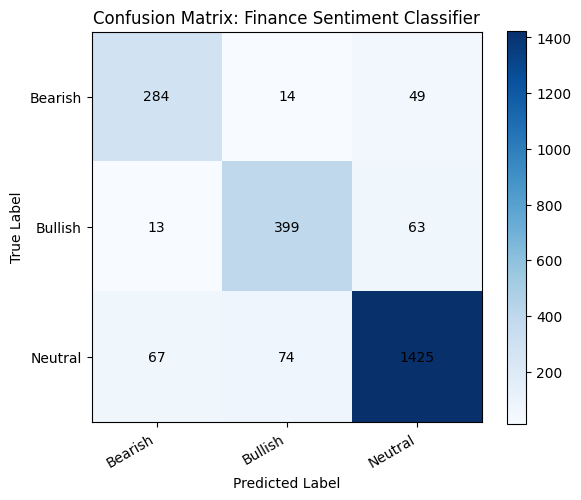

Saved confusion matrix to: valotta_unit6_finance_sentiment_model\confusion_matrix.png


In [20]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion Matrix: Finance Sentiment Classifier")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha="right")
ax.set_yticklabels(label_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
confusion_path = OUTPUT_DIR / "confusion_matrix.png"
plt.savefig(confusion_path, dpi=160)
plt.show()
print("Saved confusion matrix to:", confusion_path)

## Try the Fine-tuned Model

In [21]:
def predict_sentiment(text):
    encoded = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH)
    encoded = {key: value.to(model.device) for key, value in encoded.items()}
    model.eval()
    with torch.no_grad():
        logits = model(**encoded).logits
    probabilities = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    predicted_id = int(np.argmax(probabilities))
    return {
        "text": text,
        "prediction": id2label[predicted_id],
        "confidence": float(probabilities[predicted_id]),
        "probabilities": {id2label[i]: float(score) for i, score in enumerate(probabilities)},
    }

examples = [
    "The company reported strong revenue growth and higher operating profit.",
    "Shares fell after the firm announced a weaker outlook for next quarter.",
    "The bank said the transaction will not affect its yearly guidance.",
]

for text in examples:
    print(json.dumps(predict_sentiment(text), indent=2))

{
  "text": "The company reported strong revenue growth and higher operating profit.",
  "prediction": "Bullish",
  "confidence": 0.9992530941963196,
  "probabilities": {
    "Bearish": 0.00019932325812987983,
    "Bullish": 0.9992530941963196,
    "Neutral": 0.0005475711077451706
  }
}
{
  "text": "Shares fell after the firm announced a weaker outlook for next quarter.",
  "prediction": "Bearish",
  "confidence": 0.9990285634994507,
  "probabilities": {
    "Bearish": 0.9990285634994507,
    "Bullish": 0.00043111684499308467,
    "Neutral": 0.0005403092363849282
  }
}
{
  "text": "The bank said the transaction will not affect its yearly guidance.",
  "prediction": "Neutral",
  "confidence": 0.9990768432617188,
  "probabilities": {
    "Bearish": 0.00038124588900245726,
    "Bullish": 0.0005419405642896891,
    "Neutral": 0.9990768432617188
  }
}


## Save the Fine-tuned Model

In [22]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print("Saved fine-tuned model and tokenizer to:", OUTPUT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved fine-tuned model and tokenizer to: valotta_unit6_finance_sentiment_model


## PCA Visualization of Known Finance Word Vectors

The model's input embedding matrix contains the learned vector representation for each tokenizer token. The words below are finance-domain words. For words split into multiple WordPiece tokens, the vector is averaged across subword embeddings before PCA.

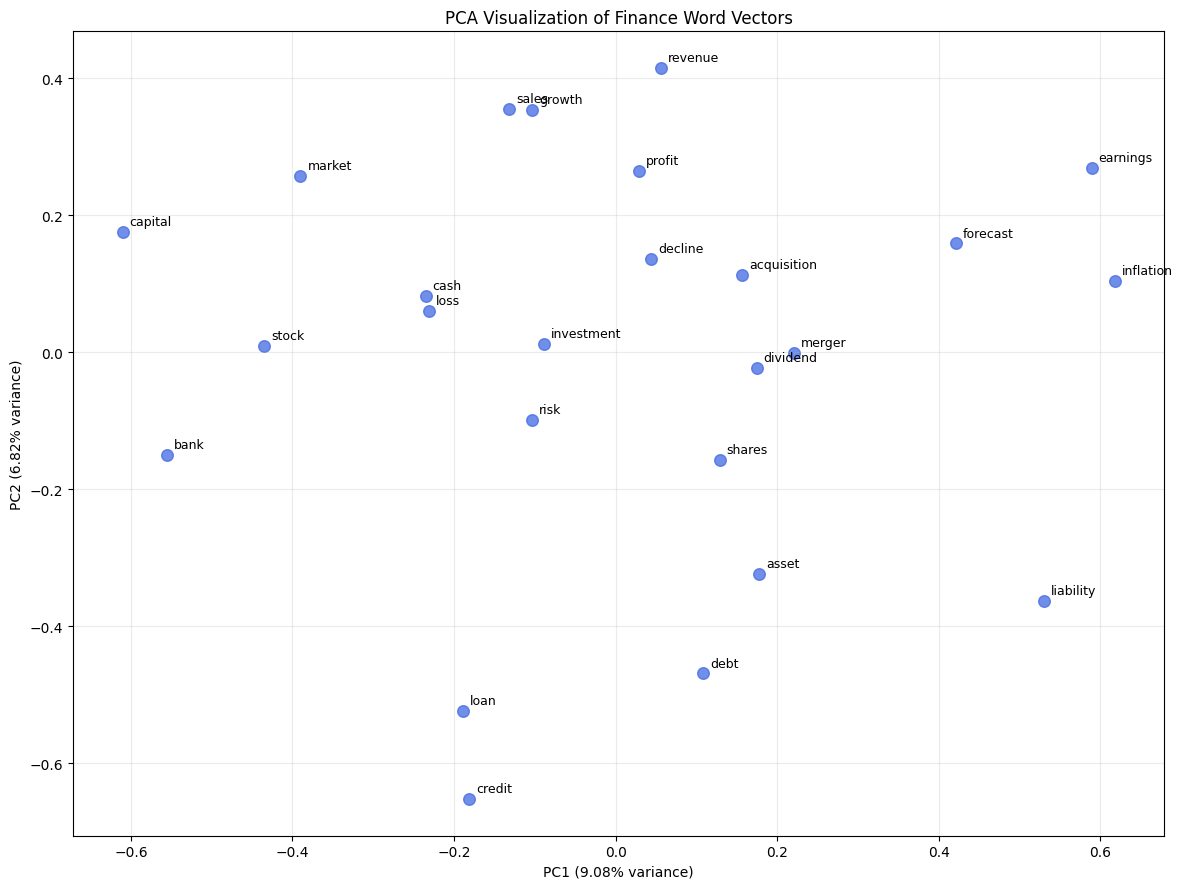

PCA words: profit, loss, revenue, sales, market, stock, shares, bank, loan, credit, debt, cash, growth, decline, investment, earnings, dividend, inflation, risk, asset, capital, forecast, merger, acquisition, liability
Saved PCA graph to: valotta_unit6_finance_sentiment_model\VALLOTA-UNIT6-PCA.png


In [23]:
finance_words = [
    "profit", "loss", "revenue", "sales", "market",
    "stock", "shares", "bank", "loan", "credit",
    "debt", "cash", "growth", "decline", "investment",
    "earnings", "dividend", "inflation", "risk", "asset",
    "capital", "forecast", "merger", "acquisition", "liability",
]

def word_embedding_from_tokens(word):
    token_ids = tokenizer.encode(word, add_special_tokens=False)
    if not token_ids:
        raise ValueError(f"No token IDs found for {word}")
    embedding_layer = model.get_input_embeddings().weight.detach().cpu()
    vectors = embedding_layer[token_ids].numpy()
    return vectors.mean(axis=0)

word_vectors = np.vstack([word_embedding_from_tokens(word) for word in finance_words])
pca = PCA(n_components=2, random_state=SEED)
word_vectors_2d = pca.fit_transform(word_vectors)

plt.figure(figsize=(12, 9))
plt.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1], s=70, color="royalblue", alpha=0.75)

for word, (x, y) in zip(finance_words, word_vectors_2d):
    plt.annotate(word, (x, y), textcoords="offset points", xytext=(5, 5), fontsize=9)

plt.title("PCA Visualization of Finance Word Vectors")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)")
plt.grid(alpha=0.25)
plt.tight_layout()

pca_path = OUTPUT_DIR / "VALLOTA-UNIT6-PCA.png"
plt.savefig(pca_path, dpi=160)
plt.show()

print("PCA words:", ", ".join(finance_words))
print("Saved PCA graph to:", pca_path)

## Summary for Report

- **Task performed:** Financial tweet sentiment classification: Bearish, Bullish, or Neutral.
- **Domain used for fine-tuning:** Finance / financial news tweets.
- **LLM used:** `distilbert-base-uncased`.
- **Fine-tuning configuration:** 5 epochs, learning rate 2e-5, batch size 8, max sequence length 128, weighted F1 used as the best-model metric.
- **Evaluation performed:** Base pretrained model vs fine-tuned model comparison using accuracy, precision, recall, F1-score, classification reports, and confusion matrix.
- **PCA performed:** 25 known finance words visualized using 2D PCA over the model's token embedding vectors.